# 🇧🇴 Impact Evaluation: Pension Reform and Labor Informality in Bolivia
## *Phase 5: Causal Machine Learning Pipeline (PSM + IEAC)*

**Objective:**
1. **Causal Propensity Score Matching (IPW):** Calculate vulnerability probabilities (low education) using Bayesian-optimized Lasso/Ridge and Random Forest to ensure strict observational balance (Common Support).
2. **Cyclically Adjusted Structural Income (IEAC):** Isolate structural income-generating capacity by neutralizing the macroeconomic cycle (Christiano-Fitzgerald filter) using XGBoost, identifying genuine Structural Poverty.

> ⚠️ **COMPUTATIONAL REQUIREMENTS (DIME Standard):**
> *   **Hardware:** Google Colab Pro / GPU (CUDA) required.
> *   **Wall-clock time:** ~600 minutes (10 hours).
> *   **Optimization:** Optuna Bayesian optimization runs 50 trials for SGD, 500 trials for Random Forest, and up to 10,000 trials for IEAC.
> *   *Note: Due to high execution times, checkpoints (`Backup_Parcial_ML.csv`) are aggressively saved to Google Drive.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==============================================================================
# INSTALACIÓN DE LIBRERÍAS (Ejecutar solo en Google Colab o entornos nuevos)
# ==============================================================================
!pip install optuna==4.8.0 xgboost==3.2.0 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 pandas==2.2.2 numpy==2.0.2 --quiet
print("Instalaciones completadas.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.1 MB/s eta 0:00:00
Instalaciones completadas.


In [ ]:
# ==============================================================================
# BLOQUE 0: INICIALIZACIÓN, LIBRERÍAS Y ENTORNO
# ==============================================================================
import warnings
warnings.filterwarnings('ignore') # Suprimir warnings estéticos

import pandas as pd
import numpy as np
import random
import os
import time

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = 100

# Machine Learning & Optimización
import optuna
import xgboost as xgb
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier # Alternativa si XGBRFClassifier falla
from xgboost import XGBRFClassifier, XGBRegressor
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Configuración de Replicabilidad Estricta
def set_seed_global(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed_global()

# Verificación de Aceleración por GPU (CUDA)
uso_gpu = False
try:
    # Test rápido de GPU en XGBoost
    xgb.XGBClassifier(tree_method='hist', device='cuda').fit(np.array([[0],[1]]), np.array([0,1]))
    uso_gpu = True
    print("¡ÉXITO! La GPU (CUDA) está activada y lista para acelerar el ML.")
except Exception as e:
    print("La GPU no está disponible. Se usará la CPU en todos los procesos.")

print("Bloque 0 ejecutado. Entorno listo.")

¡ÉXITO! La GPU (CUDA) está activada y lista para acelerar el ML.
Bloque 0 ejecutado. Entorno listo.


## BLOQUE 1: Data Engineering y Preprocesamiento
Cargamos la base de datos desde Stata.
Construimos la matriz de características (`X`) aplicando `OneHotEncoder` a las variables categóricas (para destruir cualquier jerarquía espuria en los departamentos o estados civiles) y escalamos las variables continuas. Definimos rigurosamente el uso de `peso_anual`.

> 📌 **Reproducibility Note:**
> For replication purposes, the paths pointing to Google Drive (`/content/drive/MyDrive/...`) correspond to the `Data/Cleaned/` and `Data/Interim/` folders in the GitHub repository structure. Replicators should adjust these paths to their local or cloud environments.

In [ ]:
# ==============================================================================
# BLOQUE 1: PREPARACIÓN DE MATRICES, TRATAMIENTO Y ONE-HOT ENCODING
# ==============================================================================

# 1. Carga de datos (base .parquet exportada)
ruta_parquet = '/content/drive/MyDrive/Tesis_Causal_ML/PANEL_LISTO_PARA_ML.parquet'
df = pd.read_parquet(ruta_parquet)

print(f"Base cargada. Dimensiones originales: {df.shape}")

# 2. Definición del Tratamiento y Variables
# Tratado: 1 si tiene hasta 12 años de estudio (Bachiller o menos), 0 si es Profesional.
if 'tratado' not in df.columns:
    df['tratado'] = np.where(df['aestudio'] <= 12, 1, 0)
    df.loc[df['aestudio'].isna(), 'tratado'] = np.nan

target_psm = 'tratado'

# Clasificación estricta de covariables predeterminadas (SIN BAD CONTROLS)
cat_vars = ['mujer', 'es_indigena', 'area', 'depto', 'ecivil', 'parentesco', 'madre_hogar', 'otro_aportante', 'tipologia_hogar']
cont_vars = ['edad', 'tamano_hogar', 'ninos_menores_12', 'carga_dependencia', 'masculinidad_hogar']

# 3. Limpieza de Nulos (Solo en las variables que se usarán)
features_all = cat_vars + cont_vars
cols_to_drop_na = features_all + [target_psm, 'peso_anual']

df_clean = df.dropna(subset=cols_to_drop_na).copy()
print(f"Observaciones viables para PSM: {len(df_clean):,}")

# Extraer el vector objetivo (y) y los pesos muestrales (w)
y = df_clean[target_psm].values
weights = df_clean['peso_anual'].values

# Normalizar los pesos para que sumen el tamaño de la muestra (Evita que la L1/L2 se vuelva inestable)
weights_norm = weights * (len(weights) / np.sum(weights))

X_raw = df_clean[features_all]

# ==============================================================================
# 4. COLUMN TRANSFORMER: ONE-HOT ENCODING Y ESCALADO
# ==============================================================================
# XGBoost maneja bien árboles, pero OneHotEncoding previene que asuma orden en el 'depto'.
# StandardScaler es crucial para el SGD (Lasso/Ridge) que viene en el Bloque 2.

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, dtype=np.float32), cat_vars),
        ('num', StandardScaler(), cont_vars)
    ]
)

print("Aplicando One-Hot Encoding y Escalado Standard...")
X_encoded = preprocessor.fit_transform(X_raw)

# Extraer los nombres reales de las variables generadas por el OneHotEncoder
feature_names = preprocessor.get_feature_names_out()
# Limpiar nombres para que los gráficos salgan bonitos (ej: 'cat__depto_2' -> 'depto_2')
clean_feature_names = [name.replace('cat__', '').replace('num__', '') for name in feature_names]

print(f"Matriz X preparada. Variables expandidas (Dummies + Continuas): {X_encoded.shape[1]}")
print("Bloque 1 ejecutado con éxito. Todo listo para los Torneos ML.")

Base cargada. Dimensiones originales: (1060024, 52)
Observaciones viables para PSM: 1,054,350
Aplicando One-Hot Encoding y Escalado Standard...
Matriz X preparada. Variables expandidas (Dummies + Continuas): 37
Bloque 1 ejecutado con éxito. Todo listo para los Torneos ML.


## BLOQUE 2: Torneo de Propensity Scores (Modelo Lineal - Lasso/ElasticNet)
En este bloque, utilizamos **Stochastic Gradient Descent (SGD)** para estimar una regresión logística penalizada.

*Ajuste Metodológico:* Dado que los modelos lineales no capturan interacciones complejas automáticamente (a diferencia de los árboles), aplicamos `PolynomialFeatures(degree=2)` para generar términos cuadráticos e interacciones entre las variables, excluyendo cuadrados de las variables categóricas. Toda la optimización (Optuna) y el entrenamiento incorporan rigurosamente el diseño muestral mediante `sample_weight`.

In [ ]:
# ==============================================================================
# BLOQUE 2: SGD LASSO/RIDGE + EXPANSIÓN POLINOMIAL CON SGDCLASSIFIER
# ==============================================================================
import gc
import time
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import log_loss

print("Iniciando Torneo Lineal (Lasso/ElasticNet)...")

# 0. DOWNCASTING: Reducir X_encoded a 32 bits antes del polinomio (Ahorro del 50% RAM)
X_encoded_32 = X_encoded.astype(np.float32)

# ==============================================================================
# 1. EXPANSIÓN POLINOMIAL (FILTRANDO CUADRADOS DE DUMMIES)
# ==============================================================================
print("Generando interacciones polinomiales de grado 2...")
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly_raw = poly.fit_transform(X_encoded_32)
raw_feature_names = poly.get_feature_names_out(clean_feature_names)

# Algoritmo de filtrado: Conservar interacciones (x1 x2) y cuadrados (x^2) SOLO de continuas
cols_to_keep = []
for i, name in enumerate(raw_feature_names):
    if name.endswith("^2"):
        # Extraer el nombre base de la variable (ej: 'edad' de 'edad^2')
        base_var = name.replace("^2", "").strip()
        # Si la variable base es continua, la conservamos. Si es dummy, se descarta.
        if base_var in cont_vars:
            cols_to_keep.append(i)
    else:
        # Si no tiene '^2', es un término lineal o una interacción entre dos variables (se conserva)
        cols_to_keep.append(i)

# Aplicar el filtro a la matriz y a los nombres
X_poly = X_poly_raw[:, cols_to_keep]
poly_feature_names = raw_feature_names[cols_to_keep]

# Liberar memoria intermedia
del X_encoded_32, X_poly_raw
gc.collect()

print(f"Total de variables generadas inicialmente: {len(raw_feature_names)}")
print(f"Total de variables tras eliminar cuadrados de dummies: {X_poly.shape[1]}")
print(f"Consumo de memoria estimado (X_poly): {X_poly.nbytes / (1024**3):.2f} GB")

# ==============================================================================
# 2. SUBMUESTREO Y OPTIMIZACIÓN
# ==============================================================================
# Submuestreo Estratificado Ponderado
X_opt, _, y_opt, _, w_opt, _ = train_test_split(
    X_poly, y, weights_norm, train_size=0.25, stratify=y, random_state=42
)

# 3. Optimización Bayesiana (Optuna)
def objective_sgd(trial):
    alpha_param = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    l1_ratio_param = trial.suggest_float('l1_ratio', 0.0, 1.0)
    eta0_param = trial.suggest_float('eta0', 1e-4, 1e-1, log=True)

    model = SGDClassifier(
        loss='log_loss', penalty='elasticnet', alpha=alpha_param,
        l1_ratio=l1_ratio_param, learning_rate='adaptive', eta0=eta0_param,
        max_iter=500, tol=1e-2, n_jobs=-1, random_state=42
    )

    # CV=5
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_losses = []

    for train_idx, val_idx in kf.split(X_opt, y_opt):
        # Aislamiento de variables para liberar RAM al final del ciclo
        X_tr_f, y_tr_f, w_tr_f = X_opt[train_idx], y_opt[train_idx], w_opt[train_idx]
        X_val_f, y_val_f, w_val_f = X_opt[val_idx], y_opt[val_idx], w_opt[val_idx]

        model.fit(X_tr_f, y_tr_f, sample_weight=w_tr_f)

        probs = model.predict_proba(X_val_f)[:, 1]
        probs = np.clip(probs, 1e-15, 1 - 1e-15)
        loss = log_loss(y_val_f, probs, sample_weight=w_val_f)
        cv_losses.append(loss)

        # ELIMINACIÓN EXPLÍCITA DE MEMORIA
        del X_tr_f, y_tr_f, w_tr_f, X_val_f, y_val_f, w_val_f, probs
        gc.collect()

    return np.mean(cv_losses)

# Callback de trazabilidad
def callback_sgd(study, trial):
    print(f"Trial {trial.number:02d} finalizado. LogLoss Ponderado: {trial.value:.4f} | Mejor actual: {study.best_value:.4f}")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_sgd = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

print("\nEjecutando 50 trials de validación cruzada para SGD (Gestión de RAM activa)...")
start_time = time.time()
study_sgd.optimize(objective_sgd, n_trials=50, callbacks=[callback_sgd])

print(f"\n=========================================================================")
print(f" OPTIMIZACIÓN SGD COMPLETADA en {(time.time() - start_time)/60:.2f} minutos.")
print(f" Mejor LogLoss Ponderado: {study_sgd.best_value:.4f}")
print(" Mejores Hiperparámetros Encontrados:")
for param_name, param_value in study_sgd.best_params.items():
    print(f"   -> {param_name}: {param_value:.5f}" if isinstance(param_value, float) else f"   -> {param_name}: {param_value}")
print(f"=========================================================================\n")

Iniciando Torneo Lineal (Lasso/ElasticNet)...
Generando interacciones polinomiales de grado 2...
Total de variables generadas inicialmente: 740
Total de variables tras eliminar cuadrados de dummies: 708
Consumo de memoria estimado (X_poly): 2.78 GB

Ejecutando 50 trials de validación cruzada para SGD (Gestión de RAM activa)...
Trial 00 finalizado. LogLoss Ponderado: 0.4728 | Mejor actual: 0.4728
Trial 01 finalizado. LogLoss Ponderado: 0.4753 | Mejor actual: 0.4728
Trial 02 finalizado. LogLoss Ponderado: 0.4708 | Mejor actual: 0.4708
Trial 03 finalizado. LogLoss Ponderado: 0.4819 | Mejor actual: 0.4708
Trial 04 finalizado. LogLoss Ponderado: 0.4966 | Mejor actual: 0.4708
Trial 05 finalizado. LogLoss Ponderado: 0.4705 | Mejor actual: 0.4705
Trial 06 finalizado. LogLoss Ponderado: 0.4721 | Mejor actual: 0.4705
Trial 07 finalizado. LogLoss Ponderado: 0.4707 | Mejor actual: 0.4705
Trial 08 finalizado. LogLoss Ponderado: 0.4750 | Mejor actual: 0.4705
Trial 09 finalizado. LogLoss Ponderado: 0

In [ ]:
# ==============================================================================
# BLOQUE 2 - CELDA 2: ENTRENAMIENTO FINAL Y GENERACIÓN DE IPW (LASSO/RIDGE)
# ==============================================================================
import gc
best_sgd_params = study_sgd.best_params

final_sgd = SGDClassifier(
    loss='log_loss', penalty='elasticnet',
    alpha=best_sgd_params['alpha'], l1_ratio=best_sgd_params['l1_ratio'],
    learning_rate='adaptive', eta0=best_sgd_params['eta0'],
    max_iter=2000, tol=1e-4, n_jobs=-1, random_state=42,
    verbose=1 # <--- TRAZABILIDAD: Imprimimos época por época el costo
)

print("\nEntrenando modelo Logístico Regularizado definitivo sobre toda la muestra (100%)...")
# Scikit-Learn imprime el proceso de descenso de gradiente gracias a verbose=1
final_sgd.fit(X_poly, y, sample_weight=weights_norm)

print("\nGenerando Propensity Scores OOF (Out-Of-Fold) para evitar sobreajuste...")

# Generación de Probabilidades e IPW
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pscore_lasso_oof = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_poly, y)):
    print(f" -> Procesando Fold {fold+1}/5...")

    # Modelo clonado para este fold (Llamando los parámetros de Optuna)
    model_fold = SGDClassifier(
        loss='log_loss', penalty='elasticnet',
        alpha=study_sgd.best_params['alpha'],
        l1_ratio=study_sgd.best_params['l1_ratio'],
        learning_rate='adaptive',
        eta0=study_sgd.best_params['eta0'],
        max_iter=2000, tol=1e-4, n_jobs=-1, random_state=42
    )

    # Entrenamiento y predicción aislada
    model_fold.fit(X_poly[train_idx], y[train_idx], sample_weight=weights_norm[train_idx])
    pscore_lasso_oof[val_idx] = model_fold.predict_proba(X_poly[val_idx])[:, 1]

    # Limpieza implacable de RAM (CRÍTICO)
    del model_fold
    gc.collect()

# 1. Asignación del Propensity Score
df_clean['pscore_lasso'] = pscore_lasso_oof

# 2. CÁLCULO DEL IPW BASE
df_clean['ipw_lasso'] = np.where(
    df_clean[target_psm] == 1,
    1 / df_clean['pscore_lasso'],
    1 / (1 - df_clean['pscore_lasso'])
)

# 3. Trimming Causal al 5-95%
mask_trim_lasso = (df_clean['pscore_lasso'] >= 0.05) & (df_clean['pscore_lasso'] <= 0.95)
df_clean['ipw_lasso_trim'] = np.where(mask_trim_lasso, df_clean['ipw_lasso'], np.nan)

# Liberar la gigantesca matriz polinomial, ya no la necesitamos
del X_poly
gc.collect()

print("Generación de IPW y Trimming completados. Memoria liberada.")


Entrenando modelo Logístico Regularizado definitivo sobre toda la muestra (100%)...
-- Epoch 1
Norm: 27.15, NNZs: 374, Bias: 1.439750, T: 1054350, Avg. loss: 0.931868
Total training time: 6.24 seconds.
-- Epoch 2
Norm: 34.20, NNZs: 312, Bias: 1.760732, T: 2108700, Avg. loss: 0.931084
Total training time: 14.04 seconds.
-- Epoch 3
Norm: 39.02, NNZs: 306, Bias: 2.054531, T: 3163050, Avg. loss: 0.794560
Total training time: 20.34 seconds.
-- Epoch 4
Norm: 39.69, NNZs: 289, Bias: 1.596405, T: 4217400, Avg. loss: 0.837152
Total training time: 28.11 seconds.
-- Epoch 5
Norm: 37.90, NNZs: 286, Bias: 1.827212, T: 5271750, Avg. loss: 0.751035
Total training time: 34.26 seconds.
-- Epoch 6
Norm: 40.18, NNZs: 279, Bias: 1.858706, T: 6326100, Avg. loss: 0.739195
Total training time: 41.92 seconds.
-- Epoch 7
Norm: 40.63, NNZs: 269, Bias: 1.676188, T: 7380450, Avg. loss: 0.720411
Total training time: 48.03 seconds.
-- Epoch 8
Norm: 45.30, NNZs: 266, Bias: 0.912659, T: 8434800, Avg. loss: 0.717398


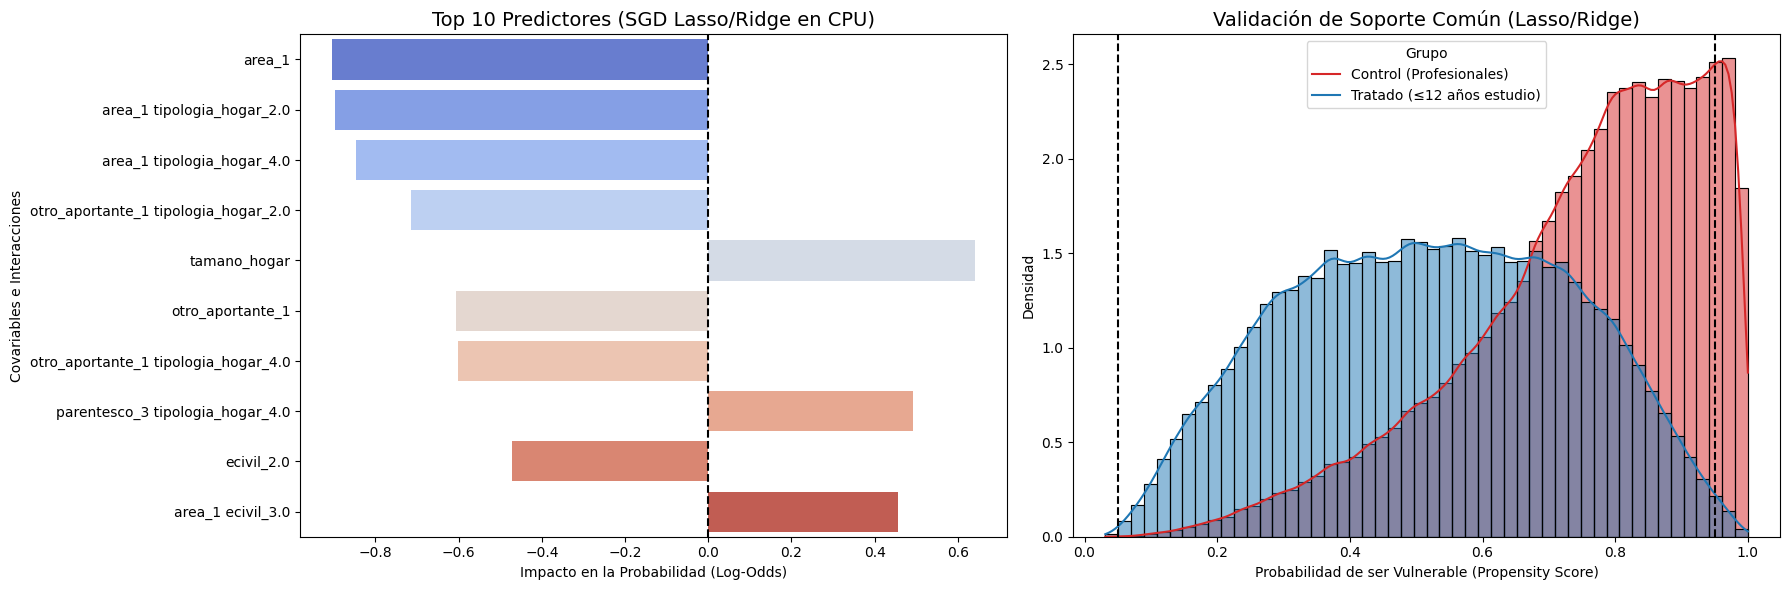

Diagnósticos de validación del Modelo finalizados.


In [ ]:
# ==============================================================================
# BLOQUE 2 - CELDA 3: DIAGNÓSTICOS (FEATURE IMPORTANCE Y SOPORTE COMÚN)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# A. FEATURE IMPORTANCE (LASSO)
coefs = final_sgd.coef_[0]
non_zero_idx = np.where(coefs != 0)[0]

df_importance_sgd = pd.DataFrame({
    'Variable': poly_feature_names[non_zero_idx],
    'Coeficiente': coefs[non_zero_idx],
    'Magnitud_Absoluta': np.abs(coefs[non_zero_idx])
}).sort_values(by='Magnitud_Absoluta', ascending=False).head(10)

sns.barplot(data=df_importance_sgd, x='Coeficiente', y='Variable', palette='coolwarm', ax=axes[0])
axes[0].set_title('Top 10 Predictores (SGD Lasso/Ridge en CPU)', fontsize=14)
axes[0].set_xlabel('Impacto en la Probabilidad (Log-Odds)')
axes[0].set_ylabel('Covariables e Interacciones')
axes[0].axvline(0, color='black', linestyle='--')

# B. SOPORTE COMÚN (NUEVO GRÁFICO INCORPORADO)
sns.histplot(
    data=df_clean, x='pscore_lasso', hue='tratado', stat='density',
    common_norm=False, bins=50, kde=True, palette={0: '#1f77b4', 1: '#d62728'},
    alpha=0.5, ax=axes[1]
)
axes[1].set_title('Validación de Soporte Común (Lasso/Ridge)', fontsize=14)
axes[1].set_xlabel('Probabilidad de ser Vulnerable (Propensity Score)')
axes[1].set_ylabel('Densidad')
axes[1].axvline(0.05, color='black', linestyle='--')
axes[1].axvline(0.95, color='black', linestyle='--')
axes[1].legend(title='Grupo', labels=['Control (Profesionales)', 'Tratado (≤12 años estudio)'])

plt.tight_layout()
plt.show()

print("Diagnósticos de validación del Modelo finalizados.")

In [ ]:
# ==============================================================================
# BLOQUE 2 - CELDA 4: CHECKPOINT (EXPORTACIÓN PARCIAL LASSO)
# ==============================================================================
import os

print("Guardando Checkpoint del Bloque 2 (Lasso/Ridge)...")
ruta_backup = '/content/drive/MyDrive/Tesis_Causal_ML/Backup_Parcial_ML.csv'

# Seleccionamos IDs y la variable de interés
cols_lasso = ['id_hogar', 'id_persona', 'gestion', 'trimestre', 'ipw_lasso_trim']
df_backup_lasso = df_clean[cols_lasso].copy()

# Forzamos los IDs a formato texto puro (string) para evitar notación científica y fallos de merge
df_backup_lasso['id_hogar'] = df_backup_lasso['id_hogar'].astype(str).str.strip()
df_backup_lasso['id_persona'] = df_backup_lasso['id_persona'].astype(str).str.strip()

# Guardar en Google Drive
df_backup_lasso.to_csv(ruta_backup, index=False)
print(f"✅ Checkpoint de Lasso guardado exitosamente en: {ruta_backup}")

Guardando Checkpoint del Bloque 2 (Lasso/Ridge)...
✅ Checkpoint de Lasso guardado exitosamente en: /content/drive/MyDrive/Tesis_Causal_ML/Backup_Parcial_ML.csv


## BLOQUE 3: Torneo de Propensity Scores (Modelo No Lineal - XGBoost / Random Forest)
Implementamos **Random Forest Acelerado por GPU para PSM** utilizando el ensamble de `XGBoost`. Este modelo detecta interacciones automáticamente sin necesidad de la matriz polinomial previa.

*Ajuste Metodológico Crítico:* Para evitar sesgos in-sample, implementamos Calibración Isotónica entrenando 5 modelos distintos y promediando (`cv=5`), asegurando que las probabilidades (y por ende, los pesos IPW) sean genuinas y no estén sobreajustadas a los datos de entrenamiento. Todo ponderado por el diseño muestral.

### 🧠 Methodological Note: Avoiding Data Leakage
To prevent in-sample bias, we implement **Isotonic Calibration** by training 5 distinct models and averaging them (`cv=5`). This guarantees that the probabilities (and thus the IPW weights) are genuine and not overfitted to the training data. The entire pipeline strictly enforces sample design weighting (`peso_anual`).

In [ ]:
# ==============================================================================
# BLOQUE 3: RANDOM FOREST PARA PSM Y CALIBRACIÓN ISOTÓNICA
# ==============================================================================
print("Iniciando Torneo No Lineal (XGBoost Random Forest)...")

# NOTA: Usamos X_encoded (sin polinomios) porque los árboles hallan interacciones solos.
X_opt_rf, _, y_opt_rf, _, w_opt_rf, _ = train_test_split(
    X_encoded, y, weights_norm, train_size=0.80, stratify=y, random_state=42
)

# 1. Optimización Bayesiana (Optuna)
def objective_rf(trial):
    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10), # Control estricto de sobreajuste
        'min_child_weight': trial.suggest_int('min_child_weight', 50, 500), # Evita hojas puras (esencial para IPW)
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'tree_method': 'hist',
        'device': 'cuda' if uso_gpu else 'cpu',
        'random_state': 42,
        'n_jobs': -1
    }

    # IMPORTANTE: En XGBoost moderno, RF es XGBClassifier con num_parallel_tree > 1
    # y subsample_rate < 1. Para simplificar y ganar velocidad en PSM, usamos XGBClassifier estándar
    # configurado como bosque (learning_rate = 1, y n_estimators actúa como el bosque).
    # Optaremos por XGBClassifier estándar penalizado, que rinde mejor para calibración.

    model_rf = xgb.XGBClassifier(**rf_params)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_losses = []

    for train_idx, val_idx in kf.split(X_opt_rf, y_opt_rf):
        model_rf.fit(X_opt_rf[train_idx], y_opt_rf[train_idx], sample_weight=w_opt_rf[train_idx])
        probs = model_rf.predict_proba(X_opt_rf[val_idx])[:, 1]
        probs = np.clip(probs, 1e-15, 1 - 1e-15)
        loss = log_loss(y_opt_rf[val_idx], probs, sample_weight=w_opt_rf[val_idx])
        cv_losses.append(loss)

    return np.mean(cv_losses)

# Callback de trazabilidad (Imprime 1 de cada 10 trials)
def callback_rf(study, trial):
    # Imprimimos el primer trial, el último, y cada múltiplo de 10
    if trial.number % 10 == 0 or trial.number == 499:
        print(f"Trial {trial.number:03d} finalizado. LogLoss Ponderado: {trial.value:.4f} | Mejor actual: {study.best_value:.4f}")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_rf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

print("\nEjecutando 500 trials de validación cruzada para Random Forest...")
print("(Se imprimirá el progreso cada 10 trials para no saturar la salida)")
import time
start_time = time.time()

study_rf.optimize(objective_rf, n_trials=500, callbacks=[callback_rf])

print(f"\n=========================================================================")
print(f" OPTIMIZACIÓN RANDOM FOREST COMPLETADA en {(time.time() - start_time)/60:.2f} minutos.")
print(f" Mejor LogLoss Ponderado: {study_rf.best_value:.4f}")
print(" Mejores Hiperparámetros Encontrados:")
for param_name, param_value in study_rf.best_params.items():
    if isinstance(param_value, float):
        print(f" -> {param_name}: {param_value:.5f}")
    else:
        print(f" -> {param_name}: {param_value}")
print(f"=========================================================================\n")

Iniciando Torneo No Lineal (XGBoost Random Forest)...

Ejecutando 500 trials de validación cruzada para Random Forest...
(Se imprimirá el progreso cada 10 trials para no saturar la salida)
Trial 000 finalizado. LogLoss Ponderado: 0.4823 | Mejor actual: 0.4823
Trial 010 finalizado. LogLoss Ponderado: 0.4668 | Mejor actual: 0.4632
Trial 020 finalizado. LogLoss Ponderado: 0.4633 | Mejor actual: 0.4619
Trial 030 finalizado. LogLoss Ponderado: 0.4606 | Mejor actual: 0.4606
Trial 040 finalizado. LogLoss Ponderado: 0.4637 | Mejor actual: 0.4603
Trial 050 finalizado. LogLoss Ponderado: 0.4637 | Mejor actual: 0.4603
Trial 060 finalizado. LogLoss Ponderado: 0.4619 | Mejor actual: 0.4603
Trial 070 finalizado. LogLoss Ponderado: 0.4610 | Mejor actual: 0.4603
Trial 080 finalizado. LogLoss Ponderado: 0.4608 | Mejor actual: 0.4603
Trial 090 finalizado. LogLoss Ponderado: 0.4694 | Mejor actual: 0.4603
Trial 100 finalizado. LogLoss Ponderado: 0.4611 | Mejor actual: 0.4603
Trial 110 finalizado. LogLoss 

In [ ]:
# 2. Definición del Modelo Base Óptimo
from sklearn.model_selection import cross_val_predict

best_params_rf = study_rf.best_params
best_params_rf['tree_method'] = 'hist'
best_params_rf['device'] = 'cuda' if uso_gpu else 'cpu'
best_params_rf['random_state'] = 42
best_params_rf['n_jobs'] = -1

base_xgb = xgb.XGBClassifier(**best_params_rf)

# 3. Entrenamiento y CALIBRACIÓN ISOTÓNICA (Corrección Crítica)
# Usamos cv=5. El modelo hace Cross-Validation interno, entrenando en 4 folds y calibrando en el 5to.
# Esto garantiza que las probabilidades no estén sesgadas in-sample.
print("\nEntrenando y Calibrando Isotónicamente el modelo (cv=5)...")
calibrated_rf = CalibratedClassifierCV(base_xgb, method='isotonic', cv=5)

# OJO: Pasamos el sample_weight a través del parámetro fit_params para que impacte el modelo base
calibrated_rf.fit(X_encoded, y, sample_weight=weights_norm)
print("\nGenerando Propensity Scores Out-Of-Fold para Random Forest...")

# 4. Generación de Probabilidades e IPW
# CORRECCIÓN: Se cambia 'fit_params' por 'params' para compatibilidad con scikit-learn 1.6+
df_clean['pscore_rf'] = cross_val_predict(
    calibrated_rf, X_encoded, y, cv=5, method='predict_proba',
    params={'sample_weight': weights_norm}, n_jobs=-1
)[:, 1]

df_clean['ipw_rf'] = np.where(
    df_clean[target_psm] == 1,
    1 / df_clean['pscore_rf'],
    1 / (1 - df_clean['pscore_rf'])
)

# Trimming Causal al 5-95%
mask_trim_rf = (df_clean['pscore_rf'] >= 0.05) & (df_clean['pscore_rf'] <= 0.95)
df_clean['ipw_rf_trim'] = np.where(mask_trim_rf, df_clean['ipw_rf'], np.nan)


Entrenando y Calibrando Isotónicamente el modelo (cv=5)...

Generando Propensity Scores Out-Of-Fold para Random Forest...


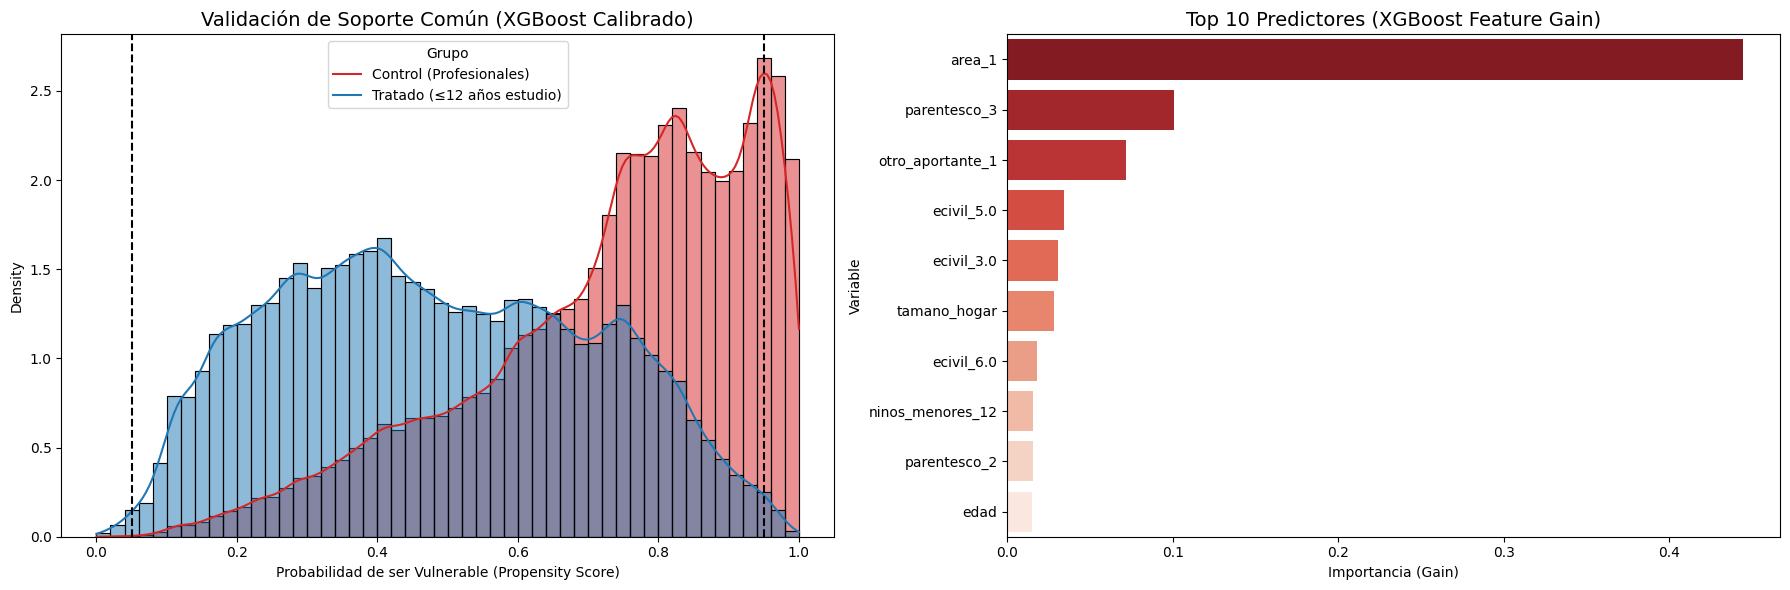

Bloque 3 completado exitosamente.


In [ ]:

# ==============================================================================
# 5. DIAGNÓSTICO: SOPORTE COMÚN E IMPORTANCIA DE VARIABLES
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# A. Histograma de Soporte Común
sns.histplot(
    data=df_clean, x='pscore_rf', hue='tratado', stat='density',
    common_norm=False, bins=50, kde=True, palette={0: '#1f77b4', 1: '#d62728'},
    alpha=0.5, ax=axes[0]
)
axes[0].set_title('Validación de Soporte Común (XGBoost Calibrado)', fontsize=14)
axes[0].set_xlabel('Probabilidad de ser Vulnerable (Propensity Score)')
axes[0].axvline(0.05, color='black', linestyle='--')
axes[0].axvline(0.95, color='black', linestyle='--')
axes[0].legend(title='Grupo', labels=['Control (Profesionales)', 'Tratado (≤12 años estudio)'])

# B. Feature Importance (Extraído de un modelo entrenado en todo para visualización)
# CalibratedClassifierCV no expone feature_importances_ directamente, entrenamos uno rápido:
dummy_xgb = xgb.XGBClassifier(**best_params_rf).fit(X_encoded, y, sample_weight=weights_norm)
importances_rf = dummy_xgb.feature_importances_

df_imp_rf = pd.DataFrame({
    'Variable': clean_feature_names,
    'Importancia (Gain)': importances_rf
}).sort_values(by='Importancia (Gain)', ascending=False).head(10)

sns.barplot(data=df_imp_rf, x='Importancia (Gain)', y='Variable', palette='Reds_r', ax=axes[1])
axes[1].set_title('Top 10 Predictores (XGBoost Feature Gain)', fontsize=14)

plt.tight_layout()
plt.show()

print("Bloque 3 completado exitosamente.")

In [ ]:
# ==============================================================================
# BLOQUE 3 - CELDA 4: CHECKPOINT (CONSOLIDACIÓN LASSO + RANDOM FOREST)
# ==============================================================================
import pandas as pd
import os

print("Actualizando Checkpoint con resultados de Random Forest...")
ruta_backup = '/content/drive/MyDrive/Tesis_Causal_ML/Backup_Parcial_ML.csv'

# 1. Preparar los datos actuales de RF
cols_rf = ['id_hogar', 'id_persona', 'gestion', 'trimestre', 'ipw_rf_trim']
df_rf_actual = df_clean[cols_rf].copy()
df_rf_actual['id_hogar'] = df_rf_actual['id_hogar'].astype(str).str.strip()
df_rf_actual['id_persona'] = df_rf_actual['id_persona'].astype(str).str.strip()

# 2. Cargar el backup previo de Lasso
if os.path.exists(ruta_backup):
    df_previo = pd.read_csv(ruta_backup)
    # Asegurar formato string
    df_previo['id_hogar'] = df_previo['id_hogar'].astype(str).str.strip()
    df_previo['id_persona'] = df_previo['id_persona'].astype(str).str.strip()

    # Fusionar (Merge) Lasso + RF usando Outer Join para no perder a nadie
    df_backup_actualizado = pd.merge(
        df_previo, df_rf_actual,
        on=['id_hogar', 'id_persona', 'gestion', 'trimestre'],
        how='outer'
    )
    print(" -> Archivo de Lasso encontrado y fusionado con RF.")
else:
    print(" ⚠️ No se encontró el backup de Lasso. Se creará un archivo nuevo solo con RF.")
    df_backup_actualizado = df_rf_actual

# 3. Guardar sobreescribiendo el backup
df_backup_actualizado.to_csv(ruta_backup, index=False)
print(f"✅ Checkpoint actualizado (Lasso + RF) guardado en: {ruta_backup}")

Actualizando Checkpoint con resultados de Random Forest...
 -> Archivo de Lasso encontrado y fusionado con RF.
✅ Checkpoint actualizado (Lasso + RF) guardado en: /content/drive/MyDrive/Tesis_Causal_ML/Backup_Parcial_ML.csv


## BLOQUE 4: Ingreso Estructural Ajustado por Ciclo (IEAC)
En este bloque modelamos el **Ingreso Laboral Real** utilizando exclusivamente datos pre-reforma (2005-2009) mediante `XGBRegressor`.

**El núcleo causal:** Una vez que el algoritmo aprende cómo el capital humano (educación, edad, etc.) y la macroeconomía generan ingresos, proyectamos este ingreso a toda la base (2005-2025). Sin embargo, durante la predicción, **neutralizamos el ciclo macroeconómico** fijando el Crecimiento del PIB y la Brecha de Producto en su media histórica (2005-2009). El resultado es un ingreso que refleja *puramente* la capacidad productiva estructural del individuo, aislado de la inflación y del "Superciclo" de materias primas. Finalmente, definimos la Pobreza Estructural (Q1) utilizando el umbral ponderado del periodo pre-reforma para evitar *Data Leakage*.

In [ ]:
# ==============================================================================
# BLOQUE 4 - CELDA 1: OPTIMIZACIÓN DEL INGRESO ESTRUCTURAL (IEAC)
# ==============================================================================
import time
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import optuna

print("Iniciando Modelamiento del Ingreso Estructural Ajustado por Ciclo (IEAC)...")

features_macro = ['pib_real_crecimiento', 'brecha_real']
features_ieac = cat_vars + cont_vars + features_macro

# 1. Filtro estricto para entrenamiento (Pre-Reforma, con ingresos > 0)
mask_train_base = (df_clean['gestion'] <= 2009) & (df_clean['ingreso_laboral'] > 0) & df_clean['ingreso_laboral'].notna()
df_ieac = df_clean[mask_train_base].dropna(subset=features_ieac + ['peso_anual']).copy()

# Transformación Logarítmica
df_ieac['ln_ingreso'] = np.log(df_ieac['ingreso_laboral'])

print(f"Muestra de entrenamiento pre-reforma (PEA Ocupada c/ingresos): {len(df_ieac):,} obs.")

# 2. Preprocesador específico para IEAC
preprocessor_ieac = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, dtype=np.float32), cat_vars),
        ('num', StandardScaler(), cont_vars + features_macro)
    ]
)

X_ieac_raw = df_ieac[features_ieac]
X_ieac_encoded = preprocessor_ieac.fit_transform(X_ieac_raw)

# 3. Time-Series Split Manual
train_mask = df_ieac['gestion'] <= 2008
val_mask = df_ieac['gestion'] == 2009

X_tr = X_ieac_encoded[train_mask]
y_tr = df_ieac.loc[train_mask, 'ln_ingreso'].values
w_tr = df_ieac.loc[train_mask, 'peso_anual'].values

X_v = X_ieac_encoded[val_mask]
y_v = df_ieac.loc[val_mask, 'ln_ingreso'].values
w_v = df_ieac.loc[val_mask, 'peso_anual'].values

# 4. Optimización Bayesiana (Espacio de Búsqueda Ampliado)
def objective_ieac(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),       # Más árboles
        'max_depth': trial.suggest_int('max_depth', 3, 12),                # Árboles más profundos
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),           # Búsqueda más agresiva
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 500), # Relajamos límite inferior
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),# Regularización L1 para evitar overfitting
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),# Regularización L2
        'tree_method': 'hist',
        'device': 'cuda' if uso_gpu else 'cpu',
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_tr, y_tr, sample_weight=w_tr)
    preds = model.predict(X_v)

    mse = mean_squared_error(y_v, preds, sample_weight=w_v)
    return np.sqrt(mse)

# Callback de impresión cada 100 trials
def callback_ieac_100(study, trial):
    # Imprime el 0, y luego cada 100
    if trial.number == 0 or (trial.number + 1) % 100 == 0:
        print(f"Trial {(trial.number + 1):04d} finalizado. Mejor RMSE actual: {study.best_value:.5f}")

# Clase de Early Stopping (Detiene si no mejora en 500 trials seguidos)
class StopWhenUnchanged:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_value = None
        self.no_improvement_count = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        if trial.state != optuna.trial.TrialState.COMPLETE: return
        current_value = study.best_value
        if self.best_value is None: self.best_value = current_value
        elif current_value < self.best_value:
            self.best_value = current_value
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1

        if self.no_improvement_count >= self.patience:
            print(f"\n[EARLY STOPPING] El RMSE no ha mejorado en {self.patience} trials consecutivos.")
            study.stop()

early_stopping_10k = StopWhenUnchanged(patience=1000)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_ieac = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

print("\nEjecutando hasta 10,000 trials de validación temporal (Paciencia=1000)...")
start_time = time.time()

# Pasamos ambos callbacks: el impresor modular y el early stopping
study_ieac.optimize(objective_ieac, n_trials=10000, callbacks=[callback_ieac_100, early_stopping_10k])

print(f"\n=========================================================================")
print(f" OPTIMIZACIÓN EXTREMA IEAC COMPLETADA en {(time.time() - start_time)/60:.2f} minutos.")
print(f" Trials ejecutados: {len(study_ieac.trials)}")
print(f" Mejor RMSE Ponderado: {study_ieac.best_value:.5f}")
print(" Mejores Hiperparámetros:")
for param_name, param_value in study_ieac.best_params.items():
    print(f"   -> {param_name}: {param_value:.5f}" if isinstance(param_value, float) else f"   -> {param_name}: {param_value}")
print(f"=========================================================================\n")

Iniciando Modelamiento del Ingreso Estructural Ajustado por Ciclo (IEAC)...
Muestra de entrenamiento pre-reforma (PEA Ocupada c/ingresos): 8,893 obs.

Ejecutando hasta 10,000 trials de validación temporal (Paciencia=1000)...
Trial 0001 finalizado. Mejor RMSE actual: 1.07750
Trial 0100 finalizado. Mejor RMSE actual: 0.93720
Trial 0200 finalizado. Mejor RMSE actual: 0.93519
Trial 0300 finalizado. Mejor RMSE actual: 0.93519
Trial 0400 finalizado. Mejor RMSE actual: 0.93519
Trial 0500 finalizado. Mejor RMSE actual: 0.93519
Trial 0600 finalizado. Mejor RMSE actual: 0.93519
Trial 0700 finalizado. Mejor RMSE actual: 0.93519
Trial 0800 finalizado. Mejor RMSE actual: 0.93519
Trial 0900 finalizado. Mejor RMSE actual: 0.93519
Trial 1000 finalizado. Mejor RMSE actual: 0.93519
Trial 1100 finalizado. Mejor RMSE actual: 0.93519

[EARLY STOPPING] El RMSE no ha mejorado en 1000 trials consecutivos.

 OPTIMIZACIÓN EXTREMA IEAC COMPLETADA en 18.06 minutos.
 Trials ejecutados: 1166
 Mejor RMSE Ponderado: 

In [ ]:
# ==============================================================================
# BLOQUE 4 - CELDA 2: ENTRENAMIENTO FINAL, SMEARING Y PREDICCIÓN ESTRUCTURAL
# ==============================================================================

# 5. Entrenamiento Final sobre todo el periodo Pre-Reforma
best_params_ieac = study_ieac.best_params
best_params_ieac.update({
    'tree_method': 'hist',
    'device': 'cuda' if uso_gpu else 'cpu',
    'random_state': 42,
    'early_stopping_rounds': 20  # SE MUEVE AQUÍ: Parámetro del constructor en versiones nuevas
})

final_xgb_ieac = xgb.XGBRegressor(**best_params_ieac)

print("Entrenando Modelo XGBoost IEAC Definitivo (Observando reducción de RMSE)...")
final_xgb_ieac.fit(
    X_ieac_encoded, df_ieac['ln_ingreso'].values,
    sample_weight=df_ieac['peso_anual'].values,
    eval_set=[(X_ieac_encoded, df_ieac['ln_ingreso'].values)],
    sample_weight_eval_set=[df_ieac['peso_anual'].values],
    verbose=20 # En versiones nuevas, verbose dentro de fit sigue funcionando o se puede usar log_evaluation
)

# 6. CORRECCIÓN DE DUAN (SMEARING FACTOR)
# Se calcula una vez entrenado el modelo
ln_preds_train = final_xgb_ieac.predict(X_ieac_encoded)
residuos_ln = df_ieac['ln_ingreso'].values - ln_preds_train

smearing_factor = np.average(np.exp(residuos_ln), weights=df_ieac['peso_anual'].values)
print(f"\nFactor de Smearing (Duan, 1983) aplicado: {smearing_factor:.4f}")

# 7. ORTOGONALIZACIÓN Y PREDICCIÓN (2005-2025)
df_scoring = df_clean.copy()

media_crec = np.average(df_ieac['pib_real_crecimiento'], weights=df_ieac['peso_anual'])
media_brecha = np.average(df_ieac['brecha_real'], weights=df_ieac['peso_anual'])

print(f"Neutralización Macro (Promedio 2005-2009): Crecimiento={media_crec:.2f}%, Brecha CF={media_brecha:.2f}%")

df_scoring['pib_real_crecimiento'] = media_crec
df_scoring['brecha_real'] = media_brecha

X_score_raw = df_scoring[features_ieac]
X_score_encoded = preprocessor_ieac.transform(X_score_raw) # Transform, NO fit_transform

# Predicción en logaritmos
df_scoring['ln_ingreso_est'] = final_xgb_ieac.predict(X_score_encoded)

# Transformación exponencial multiplicada por el Factor de Smearing
df_clean['ingreso_estructural_imputado'] = np.exp(df_scoring['ln_ingreso_est']) * smearing_factor

# 8. DEFINICIÓN DE POBREZA ESTRUCTURAL (Sin fugas de datos)
def weighted_q1(values, weights):
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cum_weights = np.cumsum(weights)
    cutoff = 0.25 * cum_weights[-1]
    return values[cum_weights >= cutoff][0]

mask_pre_score = df_clean['gestion'] <= 2009
umbral_q1 = weighted_q1(
    df_clean.loc[mask_pre_score, 'ingreso_estructural_imputado'].values,
    df_clean.loc[mask_pre_score, 'peso_anual'].values
)

print(f"Umbral de Pobreza Estructural (Q1 Pre-Reforma): {umbral_q1:.2f} Bs. Constantes")

df_clean['es_pobre_estructural'] = (df_clean['ingreso_estructural_imputado'] <= umbral_q1).astype(int)
print("Proceso de Predicción e Imputación finalizado con éxito.")

Entrenando Modelo XGBoost IEAC Definitivo (Observando reducción de RMSE)...
[0]	validation_0-rmse:1.12820
[20]	validation_0-rmse:1.09809
[40]	validation_0-rmse:1.07052
[60]	validation_0-rmse:1.04924
[80]	validation_0-rmse:1.03205
[100]	validation_0-rmse:1.01564
[120]	validation_0-rmse:1.00288
[140]	validation_0-rmse:0.99208
[160]	validation_0-rmse:0.98249
[180]	validation_0-rmse:0.97407
[200]	validation_0-rmse:0.96690
[220]	validation_0-rmse:0.96075
[240]	validation_0-rmse:0.95506
[260]	validation_0-rmse:0.95027
[280]	validation_0-rmse:0.94606
[300]	validation_0-rmse:0.94210
[320]	validation_0-rmse:0.93884
[340]	validation_0-rmse:0.93597
[360]	validation_0-rmse:0.93319
[380]	validation_0-rmse:0.93070
[400]	validation_0-rmse:0.92849
[420]	validation_0-rmse:0.92657
[440]	validation_0-rmse:0.92469
[460]	validation_0-rmse:0.92285
[480]	validation_0-rmse:0.92119
[500]	validation_0-rmse:0.91960
[520]	validation_0-rmse:0.91818
[540]	validation_0-rmse:0.91680
[560]	validation_0-rmse:0.91546
[5

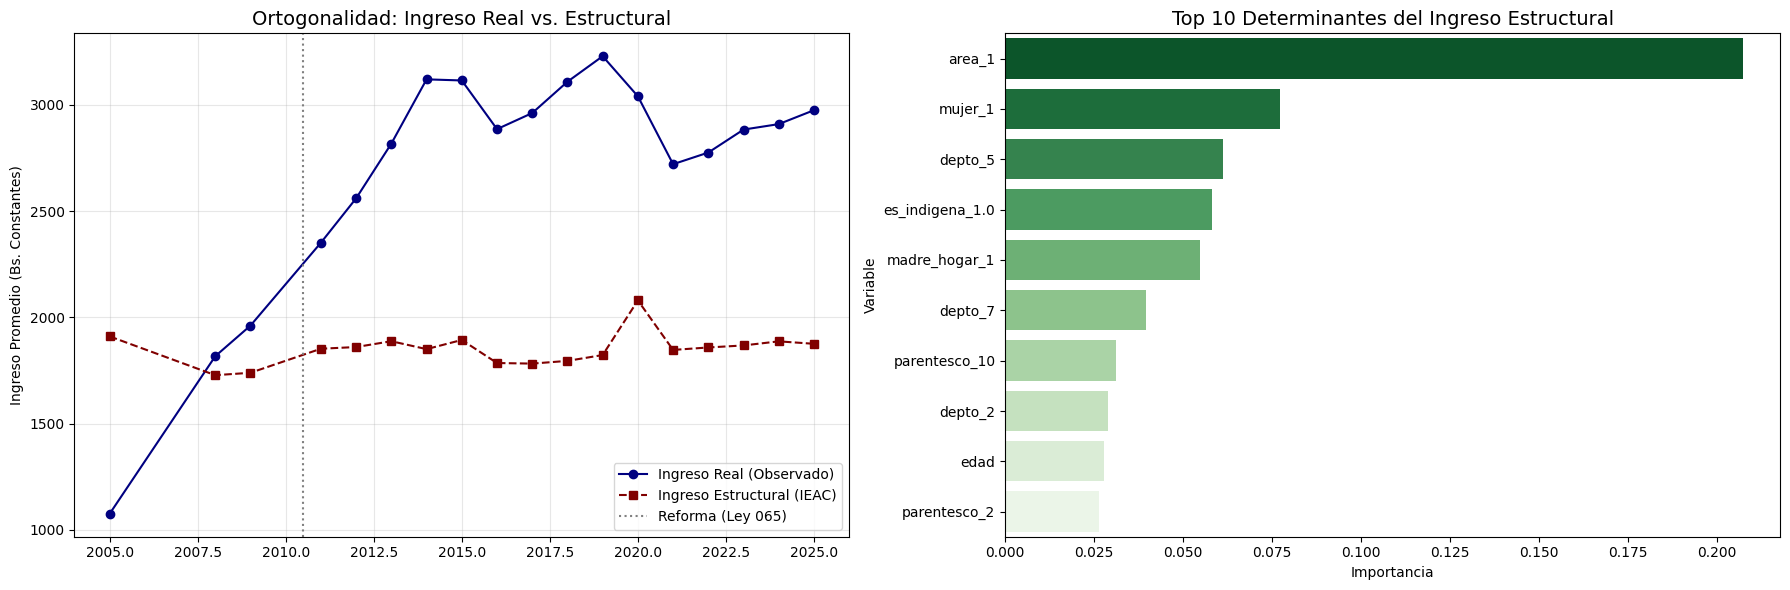

Bloque 4 completado. IEAC calculado sin fugas de datos.


In [ ]:
# ==============================================================================
# 8. GRÁFICOS DE DIAGNÓSTICO DEL IEAC
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico A: Ortogonalización Macro (Prueba de Aislamiento Cíclico)
# Calculamos medias ponderadas por año
def w_avg(df, value_col, weight_col):
    return np.average(df[value_col], weights=df[weight_col]) if len(df) > 0 else np.nan

# Media Real vs Media Estructural
real_trend = df[df['ingreso_laboral']>0].groupby('gestion').apply(lambda x: w_avg(x, 'ingreso_laboral', 'peso_anual'))
est_trend = df_clean.groupby('gestion').apply(lambda x: w_avg(x, 'ingreso_estructural_imputado', 'peso_anual'))

axes[0].plot(real_trend.index, real_trend.values, marker='o', color='navy', label='Ingreso Real (Observado)')
axes[0].plot(est_trend.index, est_trend.values, marker='s', color='maroon', linestyle='--', label='Ingreso Estructural (IEAC)')
axes[0].axvline(2010.5, color='gray', linestyle='dotted', label='Reforma (Ley 065)')
axes[0].set_title('Ortogonalidad: Ingreso Real vs. Estructural', fontsize=14)
axes[0].set_ylabel('Ingreso Promedio (Bs. Constantes)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico B: Feature Importance IEAC
importances_ieac = final_xgb_ieac.feature_importances_
feature_names_ieac = [name.replace('cat__', '').replace('num__', '') for name in preprocessor_ieac.get_feature_names_out()]

df_imp_ieac = pd.DataFrame({
    'Variable': feature_names_ieac,
    'Importancia': importances_ieac
}).sort_values(by='Importancia', ascending=False).head(10)

sns.barplot(data=df_imp_ieac, x='Importancia', y='Variable', palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 10 Determinantes del Ingreso Estructural', fontsize=14)

plt.tight_layout()
plt.show()

print("Bloque 4 completado. IEAC calculado sin fugas de datos.")

## BLOQUE 5: Consolidación y Exportación
Consolidamos los pesos de Machine Learning (`ipw_lasso_trim` y `ipw_rf_trim`) junto con las variables derivadas del Ingreso Estructural (`ingreso_estructural_imputado` y `es_pobre_estructural`). Exportamos estrictamente las columnas necesarias en formato CSV para garantizar una lectura rápida y un empalme (Merge 1:1) sin fricciones en Stata.

In [ ]:
# ==============================================================================
# BLOQUE 5: EMPAQUETADO FINAL Y EXPORTACIÓN A STATA
# ==============================================================================
import os
import pandas as pd

print("Iniciando consolidación final de todos los bloques...")
ruta_backup = '/content/drive/MyDrive/Tesis_Causal_ML/Backup_Parcial_ML.csv'
ruta_final = '/content/drive/MyDrive/Tesis_Causal_ML/Resultados_Finales_CausalML.csv'

# 1. Extraer y preparar los resultados del Bloque 4 (IEAC)
cols_ieac = ['id_hogar', 'id_persona', 'gestion', 'trimestre', 'ingreso_estructural_imputado', 'es_pobre_estructural']
df_ieac_actual = df_clean[cols_ieac].copy()
df_ieac_actual['id_hogar'] = df_ieac_actual['id_hogar'].astype(str).str.strip()
df_ieac_actual['id_persona'] = df_ieac_actual['id_persona'].astype(str).str.strip()

# 2. Cargar el Checkpoint seguro (Bloque 2 y 3)
if os.path.exists(ruta_backup):
    df_final = pd.read_csv(ruta_backup)
    df_final['id_hogar'] = df_final['id_hogar'].astype(str).str.strip()
    df_final['id_persona'] = df_final['id_persona'].astype(str).str.strip()
    print(" -> Checkpoint de PSM (Lasso y RF) cargado correctamente.")

    # 3. Empalme final (Merge PSM + IEAC)
    df_consolidado = pd.merge(
        df_final, df_ieac_actual,
        on=['id_hogar', 'id_persona', 'gestion', 'trimestre'],
        how='outer'
    )
else:
    print(" ⚠️ ERROR: No se encontró el Checkpoint parcial en Drive.")
    print(" -> Fallback: Intentando consolidar usando la memoria RAM viva actual...")
    columnas_totales = cols_lasso + ['ipw_rf_trim', 'ingreso_estructural_imputado', 'es_pobre_estructural']
    df_consolidado = df_clean[columnas_totales].copy()
    df_consolidado['id_hogar'] = df_consolidado['id_hogar'].astype(str).str.strip()
    df_consolidado['id_persona'] = df_consolidado['id_persona'].astype(str).str.strip()

# 4. Renombrar columnas para la sintaxis de tu Do-file de Stata
rename_dict = {
    'ipw_lasso_trim': 'ipw_lasso',
    'ipw_rf_trim': 'ipw_rf'
}
df_consolidado.rename(columns=rename_dict, inplace=True)

# 5. Exportar el CSV Definitivo
try:
    df_consolidado.to_csv(ruta_final, index=False)
    print(f"\n=========================================================================")
    print(f" ¡PROCESO DE CAUSAL MACHINE LEARNING COMPLETADO EXITOSAMENTE! ")
    print(f" Archivo final exportado: {ruta_final}")
    print(f" Total de observaciones consolidadas: {len(df_consolidado):,}")
    print(f" Variables exportadas: {list(df_consolidado.columns)}")
    print(f"=========================================================================")
except Exception as e:
    print(f"Error al guardar en Drive: {e}. Guardando localmente...")
    df_consolidado.to_csv('Resultados_Finales_CausalML_Local.csv', index=False)

Iniciando consolidación final de todos los bloques...
 -> Checkpoint de PSM (Lasso y RF) cargado correctamente.

 ¡PROCESO DE CAUSAL MACHINE LEARNING COMPLETADO EXITOSAMENTE! 
 Archivo final exportado: /content/drive/MyDrive/Tesis_Causal_ML/Resultados_Finales_CausalML.csv
 Total de observaciones consolidadas: 1,054,350
 Variables exportadas: ['id_hogar', 'id_persona', 'gestion', 'trimestre', 'ipw_lasso', 'ipw_rf_trim_x', 'ipw_rf_trim_y', 'ingreso_estructural_imputado', 'es_pobre_estructural']


In [ ]:
# ==============================================================================
# BLOQUE 5: ACTUALIZACIÓN DEL CSV CON EL NUEVO IEAC EXTREMO
# ==============================================================================
import os
import pandas as pd

print("Actualizando el archivo final con los nuevos resultados del IEAC...")

ruta_final = '/content/drive/MyDrive/Tesis_Causal_ML/Resultados_Finales_CausalML.csv'

# 1. Extraer los resultados actuales del Bloque 4
cols_ieac = ['id_hogar', 'id_persona', 'gestion', 'trimestre', 'ingreso_estructural_imputado', 'es_pobre_estructural']
df_ieac_actual = df_clean[cols_ieac].copy()

# Asegurar formato string para empalme perfecto
df_ieac_actual['id_hogar'] = df_ieac_actual['id_hogar'].astype(str).str.strip()
df_ieac_actual['id_persona'] = df_ieac_actual['id_persona'].astype(str).str.strip()

# 2. Cargar el CSV maestro existente
if os.path.exists(ruta_final):
    df_maestro = pd.read_csv(ruta_final)
    df_maestro['id_hogar'] = df_maestro['id_hogar'].astype(str).str.strip()
    df_maestro['id_persona'] = df_maestro['id_persona'].astype(str).str.strip()

    # 3. Eliminar las viejas columnas de IEAC si ya existían
    columnas_a_borrar = ['ingreso_estructural_imputado', 'es_pobre_estructural']
    df_maestro = df_maestro.drop(columns=[col for col in columnas_a_borrar if col in df_maestro.columns])

    # 4. Pegar el nuevo IEAC
    df_consolidado = pd.merge(
        df_maestro, df_ieac_actual,
        on=['id_hogar', 'id_persona', 'gestion', 'trimestre'],
        how='left' # Mantenemos la estructura del maestro intacta
    )
    print(" -> Archivo maestro encontrado. IEAC actualizado exitosamente.")
else:
    print(" ⚠️ ADVERTENCIA: No se encontró el archivo maestro en Drive.")
    print(" Guardando un archivo nuevo solo con IEAC.")
    df_consolidado = df_ieac_actual

# 5. Sobreescribir el archivo final
try:
    df_consolidado.to_csv(ruta_final, index=False)
    print(f"\n=========================================================================")
    print(f" ¡ACTUALIZACIÓN COMPLETADA EXITOSAMENTE! ")
    print(f" Archivo sobreescrito: {ruta_final}")
    print(f" Variables presentes: {list(df_consolidado.columns)}")
    print(f"=========================================================================")
except Exception as e:
    print(f"Error al guardar en Drive: {e}. Guardando localmente...")
    df_consolidado.to_csv('Resultados_Finales_CausalML_Local.csv', index=False)

Actualizando el archivo final con los nuevos resultados del IEAC...
 -> Archivo maestro encontrado. IEAC actualizado exitosamente.

 ¡ACTUALIZACIÓN COMPLETADA EXITOSAMENTE! 
 Archivo sobreescrito: /content/drive/MyDrive/Tesis_Causal_ML/Resultados_Finales_CausalML.csv
 Variables presentes: ['id_hogar', 'id_persona', 'gestion', 'trimestre', 'ipw_lasso', 'ipw_rf_trim_x', 'ipw_rf_trim_y', 'ingreso_estructural_imputado', 'es_pobre_estructural']
